# ___Phylogenetic analysis of the FRED 4.0 subset___
----------------------

In [1]:
print(R.version$version.string)

[1] "R version 4.6.1 (2026-06-24 ucrt)"


In [2]:
suppressPackageStartupMessages({
    library("ape")
    library("phytools")
    library("U.PhyloMaker")
    library("phylolm")
    library("geiger")
    library("Rphylopars")
    library("readxl")
    library("RRPP")
    library("geomorph")
    library("car")
    library("nortest")
    library("FSA")
})

In [3]:
packageVersion("phytools")

[1] '2.5.2'

In [4]:
packageVersion("U.PhyloMaker")

[1] '0.1.0'

In [5]:
packageVersion("phylolm")

[1] '2.7.0'

In [6]:
packageVersion("Rphylopars")

[1] '0.3.10'

In [7]:
packageVersion("geiger")

[1] '2.0.11'

## ___1. Phylogeny construction___
---------------------------

In [ ]:
megatree <- ape::read.tree("../../data/chapter2/uphylomaker/GBOTB.extended.TPL.tre") # TPL megatree
# the order info in the FRED 4.0 subset dataset wasn't cross checked!!!!
traits <- read.csv("../../data/chapter2/FRED/subsets/final") # FRED 4.0 subset with names reconciled with the megatree by hand
# this does not need programmatic name reconciliations
traits$binominal <- gsub(traits$binominal, pattern = ' ', replacement = '_')
synonyms <- read.csv("../../data/chapter2/wcvp/synonyms.csv") # WCVP synonyms

In [7]:
#---------------------------
# phylogeney construction
#---------------------------

# species, genus, family, species.relative, genus.relative
species_list <- data.frame(species = traits$binominal, genus = traits$F01286, family = NA, species.relative = NA, genus.relative = NA)
genus_list <- data.frame(genus = traits$F01286, family = traits$F01289) 
phy <- U.PhyloMaker::phylo.maker(sp.list = species_list, gen.list = genus_list, tree = megatree)

In [8]:
ape::write.tree(phy = phy$phylo, file = "../../data/chapter2/uphylomaker/FRED4_1301_species.tre")

In [22]:
stopifnot(all(traits[match(phy$phylo$tip.label, traits$binominal), ]$binominal == phy$phylo$tip.label))
traits <- traits[match(phy$phylo$tip.label, traits$binominal), ]
write.csv(traits, "../../data/chapter2/FRED/subsets/final_name_matched.csv", row.names = FALSE)

In [11]:
# phylogeny for subset comparison - based on the crtieria used to define fine roots

megatree <- ape::read.tree("../../data/chapter2/uphylomaker/GBOTB.extended.TPL.tre") # TPL megatree
data <- read.csv("../../data/chapter2/FRED/subsets/fineroot-comparison.csv")

species_list <- data.frame(species = data$binominal, genus = data$F01286, family = NA, species.relative = NA, genus.relative = NA)
genus_list <- data.frame(genus = data$F01286, family = data$F01289)

phy <- U.PhyloMaker::phylo.maker(sp.list = species_list, gen.list = genus_list, tree = megatree)

In [13]:
ape::write.tree(phy$phylo, file = "../../data/chapter2/uphylomaker/fineroot-comparison.tre")

In [19]:
data$binominal <- data$binominal |> gsub(pattern = ' ', replacement = '_') # replace the spaces with underscores

In [22]:
# name match the dataset to phylogeny

data <- data[match(phy$phylo$tip.label, data$binominal), ]

In [23]:
write.csv(data, "../../data/chapter2/FRED/subsets/fineroot-comparison-name-matched.csv", row.names = FALSE)

## ___2. Phylogenetic signal and pairwise relationships___
---------------------------

In [3]:
GEIGER_FITCONTINUOUS_MODEL_OPTIONS <- c("BM", "OU", "EB", "rate_trend", "lambda", "kappa", "delta", "mean_trend", "white")
PHYLOLM_PHYLOLM_MODEL_OPTIONS <- c("BM", "OUrandomRoot", "OUfixedRoot", "lambda", "kappa", "delta", "EB", # "trend", - "trend" option is problematic for ultrametric trees
                                   "GC")

In [4]:
# this phylogeny needs to be fully bifurcating with no polytomies
tree <- ape::read.tree("../../data/chapter2/uphylomaker/FRED4_1301.tre") # the phylogeny of the 1301 FRED 4.0 subset species

if(!ape::is.binary(tree)) tree <- ape::multi2di(tree, random = FALSE) # split polytomies into binary 0 length branches

# make the phylogeny completely bifurcating by replacing 0 length branches
tree$edge.length[tree$edge.length <= 0] <- rnorm(n = sum(tree$edge.length == 0), mean = 1e-6, sd = 1e-8) # replace the 0 length edges with random noise
stopifnot(!sum(tree$edge.length <= 0)) # no more 0 length branches

# this must be done after altering the branch lengths
if (!ape::is.ultrametric(tree)) tree <- phytools::force.ultrametric(tree = tree, method = "extend") # this needs to be done after replacing the 0 length branches with small non zero noise

stopifnot(ape::is.binary(tree) && ape::is.ultrametric(tree))

traits <- read.csv("../../data/chapter2/FRED/subsets/name_matched_FRED4_1301.csv", row.names = "binominal") # we need the binominal names as row names for phylolm::phylolm()

# repeat the taxonomic corrections
# traits[traits$F01286 %in% c("Parablechnum", "Lomaria", "Blechnopsis"), "F01286"] = "Blechnum"
# traits[traits$F01286 == "Pseudodiphasium", "F01286"] = "Lycopodium"
# traits[traits$F01286 %in% c("Richetia", "Rubroshorea"), "F01286"] = "Shorea"

# traits["binominal"] <- paste0(traits$F01286, '_', traits$F01287)
# stopifnot(length(traits$binominal)==length(tree$tip.label))
# stopifnot(sum(tree$tip.label %in% traits$binominal) == length(tree$tip.label))
# traits <- traits[match(tree$tip.label, traits$binominal), ] # name matching the dataset and the phylogeny

stopifnot(all(tree$tip.label==traits$binominal)) # the current traits dataset has already been name matched with the phylogeny!!!!!!!!

***************************************************************
*                          Note:                              *
*    force.ultrametric does not include a formal method to    *
*    ultrametricize a tree & should only be used to coerce    *
*   a phylogeny that fails is.ultrametric due to rounding --  *
*    not as a substitute for formal rate-smoothing methods.   *
***************************************************************


In [5]:
head(traits)

,F01286,F01289,F00679,F00679_se,F00727,F00727_se,F00709,F00709_se,state,state_source,synonym
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
Ratibida_pinnata,Ratibida,Asteraceae,-0.8209806,NA,4.025352,NA,-2.120264,NA,AM,"(Soudzilovskaia et al., 2020)","('Lepachys pinnata', 'Rudbeckia pinnata', 'Helianthus pinnatus', 'Obeliscaria pinnata')"
Heliopsis_helianthoides,Heliopsis,Asteraceae,-0.9675840,NA,4.158883,NA,-1.966113,NA,AM,"(Brundrett and Tedersoo, 2018)","('Buphthalmum helianthoides',)"
Liatris_aspera,Liatris,Asteraceae,-0.7985077,NA,4.382027,NA,-2.525729,NA,AM,(Maherali et. al. 2016),"('Lacinaria scariosa var. aspera', 'Lacinaria aspera')"
Arnica_sororia,Arnica,Asteraceae,-1.4134600,NA,4.342257,NA,-1.203973,NA,AM,"(Soudzilovskaia et al., 2020)","('Arnica fulgens var. sororia',)"
Arnica_fulgens,Arnica,Asteraceae,-0.6627150,NA,2.765172,NA,-1.124452,NA,AM,(Maherali et. al. 2016),"('Arnica montana var. fulgens',)"
Hymenoxys_richardsonii,Hymenoxys,Asteraceae,-1.2644308,NA,4.235371,NA,-1.460061,NA,AM,"(Soudzilovskaia et al., 2020)","('Picradenia richardsonii', 'Actinea richardsonii', 'Actinella richardsonii')"


In [18]:
# the tutorial uses the R library phylolm
# nlme::gls requires a correlation matrix - ape provides only limited options (Brownian, Bloomberg, Pagel et.c.) for this

suppressWarnings(
    rbind(
        SRL.RD = mapply(PHYLOLM_PHYLOLM_MODEL_OPTIONS, FUN = function (m) phylolm::phylolm(F00727 ~ F00679, data = traits, model = m, phy = tree)$aic), # SRL ~ RD
        RD.SRL = mapply(PHYLOLM_PHYLOLM_MODEL_OPTIONS, FUN = function (m) phylolm::phylolm(F00679 ~ F00727, data = traits, model = m, phy = tree)$aic) # RD ~ SRL
    )
)

,BM,OUrandomRoot,OUfixedRoot,lambda,kappa,delta,EB,GC
SRL.RD,4131.183,2792.9652,2792.9652,2278.52841,2449.4709,4028.958,4133.183,2935.8499
RD.SRL,1773.001,518.9369,518.9369,91.18185,301.7418,1673.066,1775.001,794.3364


In [12]:
suppressWarnings(
    rbind(
        SRL.RTD = mapply(PHYLOLM_PHYLOLM_MODEL_OPTIONS, FUN = function (m) phylolm::phylolm(F00727 ~ F00709, data = traits, model = m, phy = tree)$aic), # SRL ~ RTD
        RTD.SRL = mapply(PHYLOLM_PHYLOLM_MODEL_OPTIONS, FUN = function (m) phylolm::phylolm(F00709 ~ F00727, data = traits, model = m, phy = tree)$aic) # RTD ~ SRL
    )
)

,BM,OUrandomRoot,OUfixedRoot,lambda,kappa,delta,EB,GC
SRL.RTD,4546.430,3478.641,3478.641,3011.043,3172.628,4448.020,4548.430,3648.292
RTD.SRL,3212.342,2024.361,2024.361,1551.719,1742.425,3112.444,3214.342,2186.818


In [65]:
suppressWarnings(
    rbind(
        RTD.RD = mapply(PHYLOLM_PHYLOLM_MODEL_OPTIONS, FUN = function (m) phylolm::phylolm(F00709 ~ F00679, data = traits, model = m, phy = tree)$aic), # RTD ~ RD
        RD.RTD = mapply(PHYLOLM_PHYLOLM_MODEL_OPTIONS, FUN = function (m) phylolm::phylolm(F00679 ~ F00709, data = traits, model = m, phy = tree)$aic) # RD ~ RTD
    )
)

,BM,OUrandomRoot,OUfixedRoot,lambda,kappa,delta,EB,GC
RTD.RD,3754.571,2467.833,2467.833,1940.750,2097.047,3652.552,3756.571,2547.834
RD.RTD,2857.176,1725.364,1725.364,1239.566,1413.929,2757.907,2859.176,1917.285


In [11]:
table(traits$state)


   AM   EcM EcMAM   ErM    NM  NMAM 
 1097   121    20     9    16    38 

## ___Pairwise correlations with all the records___
------------------------------

In [6]:
STATE_COLOURS <- c(AM = "#E7BC0C", EcM = "#23B9AF", ErM = "#6B6CF2", NM = "#11E823", NMAM = "#2D2E30", EcMAM = "#E71A23")

In [7]:
options(repr.plot.width = 10, repr.plot.height = 10)

In [74]:
#------------
# SRL & RD
#------------

lmod <- lm(F00727 ~ F00679, data = traits)
plmod <- phylolm::phylolm(F00727 ~ F00679, data = traits, model = "lambda", phy = tree)#, lower.bound = list(alpha=1e-10), upper.bound = list(alpha=10))

png(filename = "../../plots/SRL-RD_FRED4.png", width = 10, height = 10, units = "in", res = 500)
par(mar=c(3, 3, 1, 1))
plot(F00727 ~ F00679, data = traits, xlab = "RD", ylab = "SRL", mgp=c(1.85, 0.7, 0), frame.plot = TRUE, pch = 21, bg = STATE_COLOURS[traits$state], cex.lab = 1.5, cex.axis = 1.5)
grid()
abline(lmod, col = "red")
abline(plmod, col = "blue")
legend(x = c(-2.5, -2.0), y = c(1, 1.2), legend = names(STATE_COLOURS), pt.bg = STATE_COLOURS, pch = 21, pt.cex = 3., horiz = FALSE, ncol = 2, bty = "n", y.intersp = 1.4, x.intersp = 1.2, text.width = 0.2)
dev.off()

pdf 
  2

In [13]:
summary(lmod)


Call:
lm(formula = F00727 ~ F00679, data = traits)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.85163 -0.43048 -0.06405  0.34489  3.06180 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  1.67507    0.04464   37.53   <2e-16 ***
F00679      -1.88414    0.04391  -42.91   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.7354 on 1299 degrees of freedom
Multiple R-squared:  0.5863,	Adjusted R-squared:  0.586 
F-statistic:  1841 on 1 and 1299 DF,  p-value: < 2.2e-16


In [14]:
summary(plmod)


Call:
phylolm::phylolm(formula = F00727 ~ F00679, data = traits, phy = tree, 
    model = "lambda")

   AIC logLik 
  2279  -1135 

Raw residuals:
     Min       1Q   Median       3Q      Max 
-2.98749 -0.71656 -0.37070  0.08457  2.72704 

Mean tip height: 400.7877
Parameter estimate(s) using ML:
lambda : 0.8531686
sigma2: 0.00351361 

Coefficients:
             Estimate    StdErr  t.value   p.value    
(Intercept)  2.058079  0.470378   4.3754 1.309e-05 ***
F00679      -1.772702  0.041431 -42.7868 < 2.2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-squared: 0.5849	Adjusted R-squared: 0.5846 

Note: p-values and R-squared are conditional on lambda=0.8531686.

In [20]:
#------------
# SRL & RTD
#------------

lmod <- lm(F00727 ~ F00709, data = traits)
plmod <- phylolm::phylolm(F00727 ~ F00709, data = traits, model = "lambda", phy = tree)#, lower.bound = list(alpha=1e-10), upper.bound = list(alpha=10))

png(filename = "../../plots/SRL-RTD_FRED4.png", width = 10, height = 10, units = "in", res = 500)
par(mar=c(3, 3, 1, 1))
plot(F00727 ~ F00709, data = traits, xlab = "RTD", ylab = "SRL", mgp=c(1.85, 0.7, 0), frame.plot = TRUE, pch = 21, bg = STATE_COLOURS[traits$state], cex.lab = 1.5, cex.axis = 1.5)
grid()
abline(lmod, col = "red")
abline(plmod, col = "blue")
# legend("bottomleft", legend = names(STATE_COLOURS), pt.bg = STATE_COLOURS, pch = 21, pt.cex = 1.5, horiz = FALSE, ncol = 2, bty = "n", y.intersp = 1.25, x.intersp = 0.75, text.width = 0.2)
dev.off()

pdf 
  2

In [16]:
summary(lmod)


Call:
lm(formula = F00727 ~ F00709, data = traits)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.03060 -0.69552 -0.05758  0.61428  2.88374 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  2.00493    0.05812   34.50   <2e-16 ***
F00709      -1.03227    0.03920  -26.33   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.9233 on 1299 degrees of freedom
Multiple R-squared:  0.348,	Adjusted R-squared:  0.3475 
F-statistic: 693.4 on 1 and 1299 DF,  p-value: < 2.2e-16


In [17]:
summary(plmod)


Call:
phylolm::phylolm(formula = F00727 ~ F00709, data = traits, phy = tree, 
    model = "lambda")

   AIC logLik 
  3011  -1502 

Raw residuals:
    Min      1Q  Median      3Q     Max 
-1.6976 -0.4668  0.1596  0.8618  3.0418 

Mean tip height: 400.7877
Parameter estimate(s) using ML:
lambda : 0.8144812
sigma2: 0.005262584 

Coefficients:
             Estimate    StdErr  t.value   p.value    
(Intercept)  1.930415  0.569325   3.3907 0.0007181 ***
F00709      -0.911692  0.041514 -21.9613 < 2.2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-squared: 0.2708	Adjusted R-squared: 0.2702 

Note: p-values and R-squared are conditional on lambda=0.8144812.

In [21]:
#------------
# RD & RTD
#------------

lmod <- lm(F00709 ~ F00679, data = traits)
plmod <- phylolm::phylolm(F00709 ~ F00679, data = traits, model = "lambda", phy = tree)#, lower.bound = list(alpha=1e-10), upper.bound = list(alpha=10))

png(filename = "../../plots/RTD-RD_FRED4.png", width = 10, height = 10, units = "in", res = 500)
par(mar=c(3, 3, 1, 1))
plot(F00709 ~ F00679, data = traits, xlab = "RD", ylab = "RTD", mgp=c(1.85, 0.7, 0), frame.plot = TRUE, pch = 21, bg = STATE_COLOURS[traits$state], cex.lab = 1.5, cex.axis = 1.5)
grid()
# abline(lmod, col = "red")
# abline(plmod, col = "blue")
# legend("bottomleft", legend = names(STATE_COLOURS), pt.bg = STATE_COLOURS, pch = 21, pt.cex = 1.5, horiz = FALSE, ncol = 2, bty = "n", y.intersp = 1.25, x.intersp = 0.75, text.width = 0.2)
dev.off()

pdf 
  2

In [19]:
summary(lmod)


Call:
lm(formula = F00709 ~ F00679, data = traits)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.63557 -0.35487  0.08587  0.44516  1.88227 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) -1.30082    0.03965 -32.807   <2e-16 ***
F00679       0.03337    0.03901   0.855    0.392    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.6533 on 1299 degrees of freedom
Multiple R-squared:  0.000563,	Adjusted R-squared:  -0.0002064 
F-statistic: 0.7317 on 1 and 1299 DF,  p-value: 0.3925


In [20]:
summary(plmod)


Call:
phylolm::phylolm(formula = F00709 ~ F00679, data = traits, phy = tree, 
    model = "lambda")

   AIC logLik 
1960.5 -976.2 

Raw residuals:
     Min       1Q   Median       3Q      Max 
-2.25958  0.03592  0.48359  0.84316  2.21827 

Mean tip height: 400.7877
Parameter estimate(s) using ML:
lambda : 0.8348878
sigma2: 0.002542712 

Coefficients:
             Estimate    StdErr t.value   p.value    
(Intercept) -1.762623  0.397198 -4.4376 9.865e-06 ***
F00679      -0.043338  0.036674 -1.1817    0.2375    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-squared: 0.001074	Adjusted R-squared: 0.0003048 

Note: p-values and R-squared are conditional on lambda=0.8348878.

In [120]:
# evern after accounting for phylogenetic relatedness, RD ~ SRL and SRL ~ RTD trait pairs show significant relationships
# so, next step, calculate how much phylogenetic signal is present in our continuous traits?? because the above could be a result of our dataset having little to no phylogenetic signal???

In [27]:
# INVESTIGATE THE PHYLOGENETIC SIGNAL IN THE CONTINUOUS TRAITS
# lambda method is best suited for detecting phylogenetic signals lesser (weaker) than that's expected under a BM model - not good for signals stronger than that of a BM model
# lambda < 1 corresponds to less phylogenetic signal than expected under a BM model

# all the continuous traits have already been log transformed
physig_srl <- phytools::phylosig(tree = tree, method = "lambda", x = setNames(traits$F00727, nm = rownames(traits)), test = TRUE)
physig_rd <- phytools::phylosig(tree = tree, method = "lambda", x = setNames(traits$F00679, nm = rownames(traits)), test = TRUE)
physig_rtd <- phytools::phylosig(tree = tree, method = "lambda", x = setNames(traits$F00709, nm = rownames(traits)), test = TRUE)

In [ ]:
# all the three traits have pretty similar lambda values and all of them are closer to 1.0 than to 0.0
# this tells us that we can reject the null hypothesis that lambda = 0 (with reference to the p values)
# LR stands for Likelihood Ratio

In [28]:
physig_srl


Phylogenetic signal lambda : 0.833651 
logL(lambda) : -1702.85 
LR(lambda=0) : 623.519 
P-value (based on LR test) : 1.2835e-137 


In [29]:
physig_rd


Phylogenetic signal lambda : 0.828158 
logL(lambda) : -616.319 
LR(lambda=0) : 466.128 
P-value (based on LR test) : 2.23079e-103 


In [30]:
physig_rtd


Phylogenetic signal lambda : 0.831478 
logL(lambda) : -966.91 
LR(lambda=0) : 630.01 
P-value (based on LR test) : 4.97377e-139 


In [44]:
# now test for the hypothesis that lambda = 1 (the phylogenetic signal observed is no more significant than what could be generated by a stochastic BM process)
# the $lik attribute of a phylosig object is the function used for its optimization

# likelihood of lambda = 1 is physig_srl$lik(1.00)
# then compare it to the MLE of lambda
lr_srl <- -2 * (physig_srl$lik(1.00) - physig_srl$logL) # page 97 - Phylogenetic Comparative Methods in R

# then compute the p statistic for our LR by comparing it to a chi squared dist with 1 degrees of freedom
pchisq(q = lr_srl, df = 1, lower.tail = FALSE) # p = 0, so we can reject the null hypothesis, which in this case is lambda = 1

[1] 0

In [45]:
# for RTD
pchisq(q = -2 * (physig_rtd$lik(1.00) - physig_rtd$logL), df = 1, lower.tail = FALSE)

[1] 0

In [46]:
# for RD
pchisq(q = -2 * (physig_rd$lik(1.00) - physig_rd$logL), df = 1, lower.tail = FALSE)

[1] 0

In [ ]:
# in conclusion; lambda != 1 and lambda != 0 for all the three continuous traits according to Pagel's lambda test

In [70]:
# now do Bloomberg's K test for all the three traits => most papers report both not just one
# Bloomberk's K is a normalized ratio of comparing variance among clades to variance within clades
# for a simple BM model of evolution, Bloomberg's K must be 1.00

physig_srl <- phytools::phylosig(tree = tree, method = "K", x = setNames(traits$F00727, nm = rownames(traits)), test = TRUE, nsim = 10000)
physig_rd <- phytools::phylosig(tree = tree, method = "K", x = setNames(traits$F00679, nm = rownames(traits)), test = TRUE, nsim = 10000)
physig_rtd <- phytools::phylosig(tree = tree, method = "K", x = setNames(traits$F00709, nm = rownames(traits)), test = TRUE, nsim = 10000)

In [71]:
physig_rd


Phylogenetic signal K : 0.0234281 
P-value (based on 10000 randomizations) : 1e-04 


In [72]:
physig_srl


Phylogenetic signal K : 0.0228481 
P-value (based on 10000 randomizations) : 1e-04 


In [73]:
physig_rtd


Phylogenetic signal K : 0.0319059 
P-value (based on 10000 randomizations) : 1e-04 


In [ ]:
# in our case, all the three traits show a K that is less than expected from a BM model of evolution

In [47]:
# for an explanation on non BM models - https://lukejharmon.github.io/pcm/chapter6_beyondbm/
# page 100 of Phylogenetic Comparative Methods in R
# PAY ATTENTION TO THE WARNING MESSAGES HERE!!!!!!!!

tm <- Sys.time()

SRL_model_fits <- list()
RD_model_fits <- list()
RTD_model_fits <- list()

for (m in GEIGER_FITCONTINUOUS_MODEL_OPTIONS) {
    SRL_model_fits[[m]] <- geiger::fitContinuous(phy = tree, dat = traits["F00727"], model = m)
    RD_model_fits[[m]] <- geiger::fitContinuous(phy = tree, dat = traits["F00679"], model = m)
    RTD_model_fits[[m]] <- geiger::fitContinuous(phy = tree, dat = traits["F00709"], model = m)
    print(paste0("all ", m, " fits done!"))
}

tm <- Sys.time() - tm

save(SRL_model_fits, RD_model_fits, RTD_model_fits, file = "../../data/chapter2/rdata/SRL_RD_RTD_geiger_fitContinuous.RData")

[1] "all BM fits done!"
[1] "all OU fits done!"


Warning message in geiger::fitContinuous(phy = tree, dat = traits["F00679"], model = m):
"
Parameter estimates appear at bounds:
	a"


[1] "all EB fits done!"
[1] "all rate_trend fits done!"
[1] "all lambda fits done!"
[1] "all kappa fits done!"
[1] "all delta fits done!"
[1] "all mean_trend fits done!"
[1] "all white fits done!"


In [48]:
tm # not bad at all :)

Time difference of 6.48128 mins

In [50]:
# inspect the EB models 

SRL_model_fits[["EB"]]$opt # alpha is near zero - in this case EB models regress to a constant rate BM model, this does not need to be corrected since this is not an error!
# page 101 - Phylogenetic Comparative Methods in R

$a
[1] -1.000012e-06

$sigsq
[1] 0.1739684

$z0
[1] 3.578437

$lnL
[1] -2595.165

$method
[1] "subplex"

$k
[1] 3

$aic
[1] 5196.33

$aicc
[1] 5196.349

In [21]:
load("../../data/chapter2/rdata/SRL_RD_RTD_geiger_fitContinuous.RData") # reusing the serialized model fits

# for all the three continuous traits lambda seems to be the best model, followed by kappa and then OU??????

# AICc table
aicc_table <- cbind(
    SRL = mapply(SRL_model_fits, FUN = function(m) m$opt$aicc),
    RD = mapply(RD_model_fits, FUN = function(m) m$opt$aicc),
    RTD = mapply(RTD_model_fits, FUN = function(m) m$opt$aicc)
)

aicc_table

,SRL,RD,RTD
BM,5194.320,2856.343,3753.738
OU,3929.309,1673.022,2363.545
EB,5196.349,2858.372,3755.767
rate_trend,5142.831,2805.895,3701.959
lambda,3411.727,1238.656,1939.839
kappa,3541.948,1414.503,2097.651
delta,5092.885,2757.039,3651.684
mean_trend,5196.329,2858.353,3755.747
white,4033.236,1702.775,2567.840


In [ ]:
# 

In [12]:
RD_model_fits[["lambda"]]$opt

$lambda
[1] 0.8281666

$sigsq
[1] 0.00142289

$z0
[1] -0.8023254

$lnL
[1] -616.3189

$method
[1] "subplex"

$k
[1] 3

$aic
[1] 1238.638

$aicc
[1] 1238.656

In [13]:
SRL_model_fits[["lambda"]]$opt

$lambda
[1] 0.833639

$sigsq
[1] 0.007730035

$z0
[1] 3.560545

$lnL
[1] -1702.854

$method
[1] "L-BFGS-B"

$k
[1] 3

$aic
[1] 3411.708

$aicc
[1] 3411.727

In [14]:
RTD_model_fits[["lambda"]]$opt

$lambda
[1] 0.8314678

$sigsq
[1] 0.002471727

$z0
[1] -1.710555

$lnL
[1] -966.9103

$method
[1] "L-BFGS-B"

$k
[1] 3

$aic
[1] 1939.821

$aicc
[1] 1939.839

In [ ]:
# branch length transformation

In [23]:
lapply(c(RD_model_fits["lambda"], SRL_model_fits["lambda"], RTD_model_fits["lambda"]), FUN = function(m) m$opt$lambda)

$lambda
[1] 0.8281666

$lambda
[1] 0.833639

$lambda
[1] 0.8314678

In [24]:
lapply(c(RD_model_fits["lambda"], SRL_model_fits["lambda"], RTD_model_fits["lambda"]), FUN = function(m) m$opt$lambda) |> as.numeric() |> mean()

[1] 0.8310911

In [25]:
transformed_tree <- geiger:::rescale.phylo(x = tree, model = "lambda", lambda = 0.831091127072489)

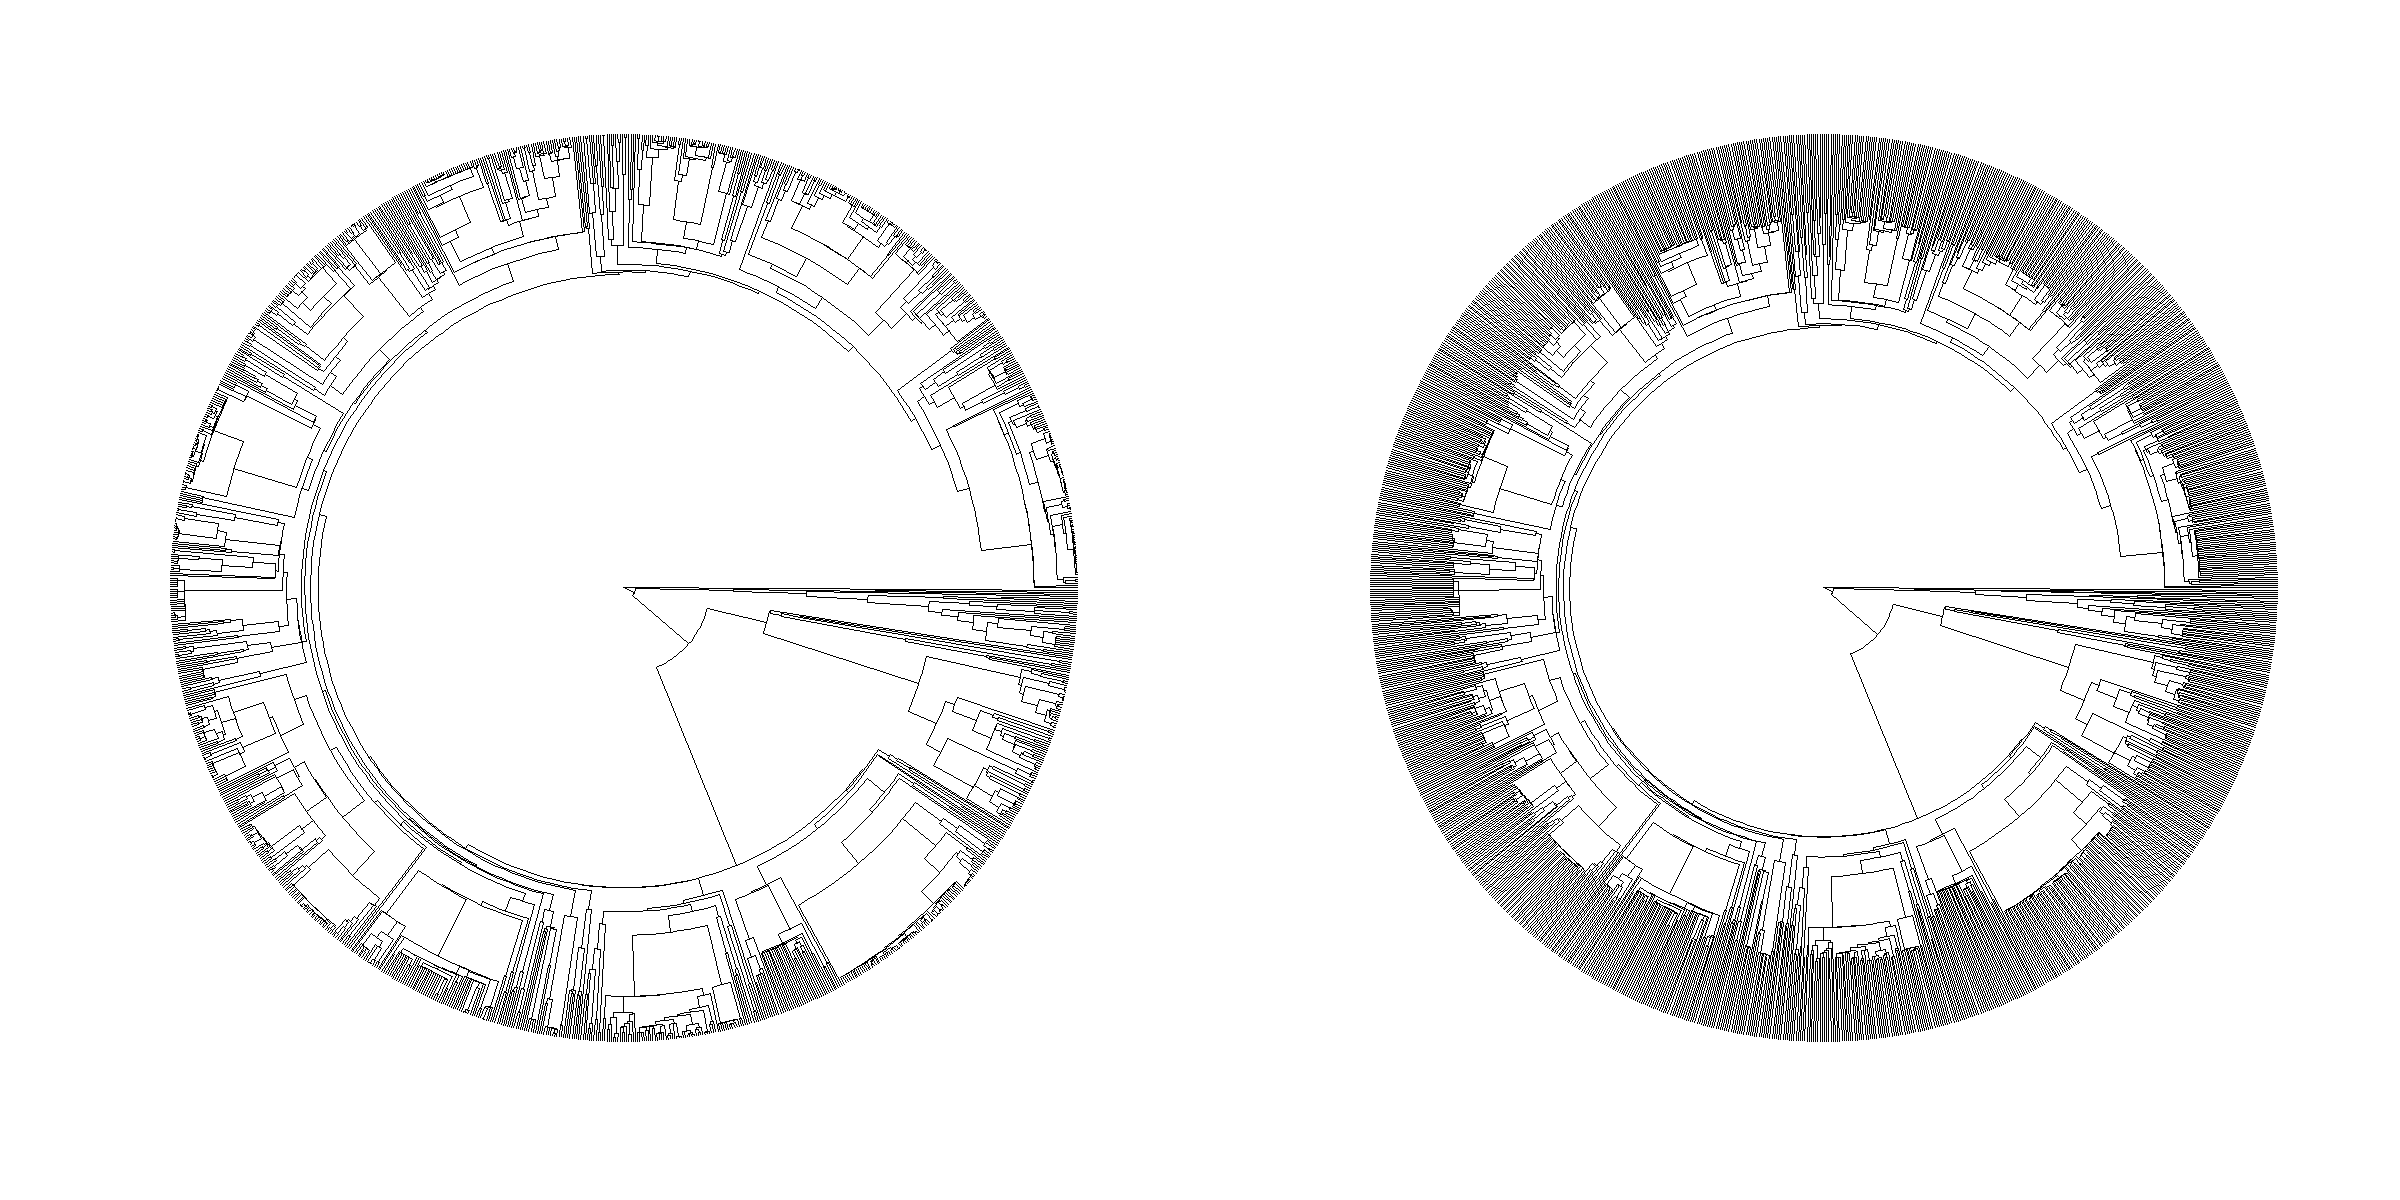

In [28]:
options(repr.plot.width = 20, repr.plot.height = 10)
par(mfcol = c(1, 2))
ape::plot.phylo(tree, type = "fan", show.tip.label = FALSE)
ape::plot.phylo(transformed_tree, type = "fan", show.tip.label = FALSE) # interesting

In [54]:
# AIC weights table

cbind(
    SRL = aic.w(mapply(SRL_model_fits, FUN = function(m) AIC(m))),
    RD = aic.w(mapply(RD_model_fits, FUN = function(m) AIC(m))),
    RTD = aic.w(mapply(RTD_model_fits, FUN = function(m) AIC(m)))
)

,SRL,RD,RTD
BM,0.000000e+00,0.000000e+00,0.000000e+00
OU,4.059008e-113,4.771765e-95,9.851911e-93
EB,0.000000e+00,0.000000e+00,0.000000e+00
rate_trend,0.000000e+00,0.000000e+00,0.000000e+00
lambda,1.000000e+00,1.000000e+00,1.000000e+00
kappa,5.281734e-29,6.536003e-39,5.388475e-35
delta,0.000000e+00,0.000000e+00,0.000000e+00
mean_trend,0.000000e+00,0.000000e+00,0.000000e+00
white,1.093630e-135,1.644340e-101,4.259908e-137


In [72]:
aicc_table

,SRL,RD,RTD
BM,5194.320,2856.343,3753.738
OU,3929.309,1673.022,2363.545
EB,5196.349,2858.372,3755.767
rate_trend,5142.831,2805.895,3701.959
lambda,3411.727,1238.656,1939.839
kappa,3541.948,1414.503,2097.651
delta,5092.885,2757.039,3651.684
mean_trend,5196.329,2858.353,3755.747
white,4033.236,1702.775,2567.840


In [68]:
fit_rd <- geiger::fitContinuous(phy = tree, dat = traits["F00679"], model = "OU")$opt
fit_srl <- geiger::fitContinuous(phy = tree, dat = traits["F00727"], model = "OU")$opt
fit_rtd <- geiger::fitContinuous(phy = tree, dat = traits["F00709"], model = "OU")$opt

In [79]:
rbind(fit_rd, fit_srl, fit_rtd) |> t() |> as.data.frame()

,fit_rd,fit_srl,fit_rtd
,<named list>,<named list>,<named list>
alpha,0.2283605,0.2347242,0.5055475
sigsq,0.1046208,0.6145754,0.3889756
z0,-0.9270203,3.377086,-1.298271
lnL,-821.7603,-1957.404,-1194.053
method,L-BFGS-B,L-BFGS-B,L-BFGS-B
k,3,3,3
aic,1649.521,3920.807,2394.105
aicc,1649.539,3920.826,2394.124


# ___`Rphylopars`___
----------------------------

In [10]:
# apparently fitting OU models in brms can be tricky - let's try Rphylopars - which allows multivariate OU models
# the trait data should have species as the first column is also species names, followed by the continuous traits - the name of the first column must be "species"
# with duplicate entries (for within species variation) - we cannot have binominal names as the rownames

fred4 <- read.csv("../../data/chapter2/FRED/subsets/continuous_raw.csv")
fred4 <- fred4[, c("binominal", "F00679", "F00727", "F00709")]
colnames(fred4)[1] = "species" # this is a requirement for the phylopars function
stopifnot(all(fred4$species %in% tree$tip.label))

fred4[, 2:4] <- fred4[, 2:4] |> log() |> apply(FUN = scale, MARGIN = 2, center = TRUE, scale = TRUE) # log transform and standardize the trait data

head(fred4) # this is also a log transformed and scaled dataset!!!!

,species,F00679,F00727,F00709
,<chr>,<dbl>,<dbl>,<dbl>
1,Larix_gmelinii,-0.86964523,0.3800732,0.51080990
2,Larix_gmelinii,-0.30989917,0.1548774,0.22220517
3,Larix_gmelinii,0.23874590,-0.4930916,0.63144285
4,Larix_gmelinii,1.28396192,-1.1952738,0.42043082
5,Larix_gmelinii,-0.95393439,0.4492205,0.63144258
6,Larix_gmelinii,-0.06701916,0.1904641,0.02954094


In [60]:
# https://github.com/ericgoolsby/Rphylopars/wiki/Example-4:-Alternative-Evolutionary-Models
# if you run into errors with mvOU models - set usezscores to FALSE as explained in this thread https://github.com/ericgoolsby/Rphylopars/issues/54

In [61]:
# Rphylopars automatically detects multiple within-species observations and estimates within-species covariance with pheno_correlated set to TRUE
# the two fits below account for within species correlations

# with a diagonal alhpa - only phylogenetic correlation between species is accounted for, evolution of traits are treated independently (no cross trait correlations)
mvOU_diagonal <- Rphylopars::phylopars(trait_data = fred4, tree = tree, phylo_correlated = TRUE, pheno_correlated = TRUE, model = "mvOU", full_alpha = FALSE, usezscores = FALSE)

# with a full alpha matrix - phylogenetic correlation between species and correlated evolution between traits are accounted for
mvOU_full <- Rphylopars::phylopars(trait_data = fred4, tree = tree, phylo_correlated = TRUE, pheno_correlated = TRUE, model = "mvOU", full_alpha = TRUE, usezscores = FALSE)

In [ ]:
# read https://support.minitab.com/en-us/minitab/help-and-how-to/statistical-modeling/anova/supporting-topics/anova-statistics/what-is-the-variance-covariance-matrix/
# to understand variance-covariance matrices
# see https://en.wikipedia.org/wiki/Covariance for covariance
# see https://stats.stackexchange.com/questions/17050/explanation-for-r-squared-as-ratio-of-covariances-and-variances for the relationship between correlation (R2) and covariance
# https://github.com/ericgoolsby/Rphylopars/issues/49

In [ ]:
# from https://github.com/ericgoolsby/Rphylopars/wiki/Example-4:-Alternative-Evolutionary-Models
# The phylogenetic trait variance-covariance is the Σ matrix of the OU process, and the stationary covariance is that same matrix divided by 2*alpha.

In [62]:
mvOU_full

Phylogenetic trait variance-covariance
            F00679      F00727      F00709
F00679  0.03094493 -0.01826736 -0.01227627
F00727 -0.01826736  0.02300304 -0.01129689
F00709 -0.01227627 -0.01129689  0.03693923

Phenotypic trait variance-covariance
            F00679     F00727      F00709
F00679  0.48128397 -0.3229709  0.01183338
F00727 -0.32297093  0.4266235 -0.19573197
F00709  0.01183338 -0.1957320  0.35233416

% variance explained by phylogeny
  F00679   F00727   F00709 
51.87160 57.33765 64.76658 
mvOU alpha = 
             F00679       F00727       F00709
F00679  0.017966975  0.001136202 -0.006836677
F00727  0.001136202  0.014354971 -0.002530329
F00709 -0.006836677 -0.002530329  0.026740089


Stationary covariance = 
            F00679     F00727      F00709
F00679  0.87695525 -0.6932728 -0.07371013
F00727 -0.69327279  0.8033726 -0.29910170
F00709 -0.07371013 -0.2991017  0.64356026


In [63]:
mvOU_diagonal

Phylogenetic trait variance-covariance
             F00679      F00727       F00709
F00679  0.032469655 -0.02322968 -0.005756741
F00727 -0.023229683  0.02651896 -0.010789750
F00709 -0.005756741 -0.01078975  0.028340213

Phenotypic trait variance-covariance
             F00679     F00727       F00709
F00679  0.480277687 -0.3206001  0.009557131
F00727 -0.320600093  0.4246606 -0.195714693
F00709  0.009557131 -0.1957147  0.354929505

% variance explained by phylogeny
  F00679   F00727   F00709 
51.97223 57.53394 64.50705 
mvOU alpha = 
           F00679    F00727     F00709
F00679 0.01919707 0.0000000 0.00000000
F00727 0.00000000 0.0179221 0.00000000
F00709 0.00000000 0.0000000 0.01976518


Stationary covariance = 
           F00679     F00727     F00709
F00679  0.8456930 -0.6258137 -0.1477517
F00727 -0.6258137  0.7398399 -0.2862968
F00709 -0.1477517 -0.2862968  0.7169226


In [64]:
summary(mvOU_diagonal)

mvOU alpha = 
           F00679    F00727     F00709
F00679 0.01919707 0.0000000 0.00000000
F00727 0.00000000 0.0179221 0.00000000
F00709 0.00000000 0.0000000 0.01976518



,phylogenetic mean,phylogenetic sd,phenotypic sd,% variance explained by phylogeny
F00679,-0.2503918,0.1802,0.6930,51.97
F00727,0.2670933,0.1628,0.6517,57.53
F00709,-0.1133140,0.1683,0.5958,64.51


In [65]:
summary(mvOU_full)

mvOU alpha = 
             F00679       F00727       F00709
F00679  0.017966975  0.001136202 -0.006836677
F00727  0.001136202  0.014354971 -0.002530329
F00709 -0.006836677 -0.002530329  0.026740089



,phylogenetic mean,phylogenetic sd,phenotypic sd,% variance explained by phylogeny
F00679,-0.29819824,0.1759,0.6937,51.87
F00727,0.24459623,0.1517,0.6532,57.34
F00709,-0.01758767,0.1922,0.5936,64.77


In [66]:
stats::AIC(mvOU_diagonal)

[1] 27556.68

In [67]:
stats::AIC(mvOU_full) # full alpha matrix has a lower AIC than the diagonal one - there's evidence to correlation between traits!!!

[1] 27541.39

In [69]:
stats::AIC(mvOU_diagonal) - stats::AIC(mvOU_full)

[1] 15.28992

In [49]:
# now onto models that don't account for within species correlations (pheno_correlated=FALSE)

mvOU_diagonal_nsp <- Rphylopars::phylopars(trait_data = fred4, tree = tree, phylo_correlated = TRUE, pheno_correlated = FALSE, model = "mvOU", full_alpha = FALSE, usezscores = FALSE)
mvOU_full_nsp <- Rphylopars::phylopars(trait_data = fred4, tree = tree, phylo_correlated = TRUE, pheno_correlated = FALSE, model = "mvOU", full_alpha = TRUE, usezscores = FALSE)

In [50]:
summary(mvOU_diagonal_nsp)

mvOU alpha = 
           F00679     F00727     F00709
F00679 0.03088403 0.00000000 0.00000000
F00727 0.00000000 0.02656244 0.00000000
F00709 0.00000000 0.00000000 0.02457418



,phylogenetic mean,phylogenetic sd,phenotypic sd,% variance explained by phylogeny
F00679,-0.33608615,0.2381,0.6670,55.51
F00727,0.31370652,0.2198,0.6185,61.75
F00709,-0.07354631,0.1880,0.5856,65.71


In [51]:
summary(mvOU_full_nsp)

mvOU alpha = 
         F00679   F00727   F00709
F00679 3.388095 3.889273 2.414048
F00727 3.889273 4.517015 2.790547
F00709 2.414048 2.790547 1.766468



,phylogenetic mean,phylogenetic sd,phenotypic sd,% variance explained by phylogeny
F00679,-0.30450758,0.1257,0.6690,55.25
F00727,0.28629208,0.2927,0.6192,61.66
F00709,-0.02332462,0.2352,0.5844,65.85


In [52]:
stats::AIC(mvOU_diagonal_nsp) # diagonal is better than full in this case

[1] 33833.58

In [53]:
stats::AIC(mvOU_full_nsp)

[1] 33843.66

In [ ]:
# since the AICs of models that did not account for within species correlation is way higher than the ones that did, there's evidence for within species correlation!!!

In [55]:
# OU model with same rates for all traits - these are not multivariate models (technically??)
# for the OU model, this is like a multivariate OU where the alpha matrix is diagonal and with identical values across the diagonal.

OU_model_base <- Rphylopars::phylopars(trait_data = fred4, tree = tree, phylo_correlated = TRUE, pheno_correlated = TRUE, model = "OU")

In [56]:
summary(OU_model_base)

OU alpha = 0.01889005


,phylogenetic mean,phylogenetic sd,phenotypic sd,% variance explained by phylogeny
F00679,-0.2486226,0.9214,0.6931,51.97
F00727,0.2711781,0.8550,0.6512,57.60
F00709,-0.1265029,0.8545,0.5960,64.48


In [58]:
stats::AIC(OU_model_base) # AIC higher than our multivariate models

[1] 27555.23

In [11]:
# also try lambda models 

# univariate lambda models - traits are correlated & within species correlations accounted for
lambda_phycorr <- Rphylopars::phylopars(trait_data = fred4, tree = tree, phylo_correlated = TRUE, pheno_correlated = TRUE, model = "lambda", usezscores = FALSE)
# univariate lambda models - traits are independent & within species correlations accounted for
lambda_phynocorr <- Rphylopars::phylopars(trait_data = fred4, tree = tree, phylo_correlated = FALSE, pheno_correlated = TRUE, model = "lambda", usezscores = FALSE)
# univariate lambda models - traits are correlated & within species correlations not accounted for
lambda_phenonocorr <- Rphylopars::phylopars(trait_data = fred4, tree = tree, phylo_correlated = TRUE, pheno_correlated = FALSE, model = "lambda", usezscores = FALSE)

In [12]:
stats::AIC(lambda_phycorr) # the lowest AIC - cross trait correlations and within species correlations accounted for

[1] 27486.16

In [13]:
stats::AIC(lambda_phynocorr)

[1] 28969.26

In [14]:
stats::AIC(lambda_phenonocorr)

[1] 33651.05

In [76]:
33651.0473971795 - 27486.1628646298

[1] 6164.885

In [15]:
lambda_phycorr

Phylogenetic trait variance-covariance
              F00679       F00727        F00709
F00679  0.0063379075 -0.004725059 -0.0008425563
F00727 -0.0047250589  0.005910638 -0.0027578717
F00709 -0.0008425563 -0.002757872  0.0059100039

Phenotypic trait variance-covariance
            F00679     F00727      F00709
F00679  0.47428995 -0.3167326  0.01236117
F00727 -0.31673258  0.4187477 -0.19249842
F00709  0.01236117 -0.1924984  0.34808464

% variance explained by phylogeny
  F00679   F00727   F00709 
52.57101 58.12523 65.19154 
lambda = 0.922766

## ___Phylogenetic ANOVA___
----------------------

In [8]:
# https://eeob-macroevolution.github.io/Practicals/MultivariatePCMs/MultivariatePCM_Tutorial.html
# http://www.phytools.org/static.help/phylANOVA.html

In [4]:
fred4_raw <- read.csv("../../data/chapter2/FRED/subsets/continuous_raw.csv")
# log transform and standardize the traits
fred4_raw[, 5:7] <- fred4_raw[, 5:7] |> log() |> scale()

head(fred4_raw)

,binominal,F01286,F01287,F01289,F00679,F00727,F00709
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
1,Larix_gmelinii,Larix,gmelinii,Pinaceae,-0.86964523,0.3800732,0.51080990
2,Larix_gmelinii,Larix,gmelinii,Pinaceae,-0.30989917,0.1548774,0.22220517
3,Larix_gmelinii,Larix,gmelinii,Pinaceae,0.23874590,-0.4930916,0.63144285
4,Larix_gmelinii,Larix,gmelinii,Pinaceae,1.28396192,-1.1952738,0.42043082
5,Larix_gmelinii,Larix,gmelinii,Pinaceae,-0.95393439,0.4492205,0.63144258
6,Larix_gmelinii,Larix,gmelinii,Pinaceae,-0.06701916,0.1904641,0.02954094


In [11]:
varcov <- ape::vcv.phylo(tree)

In [15]:
RRPP::rrpp.data.frame(Y = fred4_raw[, c("F00679", "F00727", "F00709")], taxa = fred4_raw$binominal, Cov = varcov) # won't allow multiple measurements for species????

ERROR: Error in RRPP::rrpp.data.frame(Y = fred4_raw[, c("F00679", "F00727", "F00709")], : Inputs have different numbers of observations


In [16]:
head(varcov)

,Ratibida_pinnata,Heliopsis_helianthoides,Liatris_aspera,Arnica_sororia,Arnica_fulgens,Hymenoxys_richardsonii,Helianthus_agrestis,Helianthus_grosseserratus,Helianthus_giganteus,Helianthus_maximiliani,⋯,Sphaeropteris_medullaris,Dicksonia_squarrosa,Cibotium_barometz,Sticherus_cunninghamii,Dicranopteris_pedata,Dicranopteris_linearis,Osmunda_japonica,Equisetum_hyemale,Equisetum_pratense,Lycopodium_volubile
Ratibida_pinnata,400.7877,362.4934,362.4934,362.4934,362.4934,362.4934,362.4934,362.4934,362.4934,362.4934,⋯,10.08512,10.08512,10.08512,10.08512,10.08512,10.08512,10.08512,10.08512,10.08512,0
Heliopsis_helianthoides,362.4934,400.7877,362.4934,362.4934,362.4934,362.4934,362.4934,362.4934,362.4934,362.4934,⋯,10.08512,10.08512,10.08512,10.08512,10.08512,10.08512,10.08512,10.08512,10.08512,0
Liatris_aspera,362.4934,362.4934,400.7877,390.5848,390.5848,388.3693,383.0923,383.0923,383.0923,383.0923,⋯,10.08512,10.08512,10.08512,10.08512,10.08512,10.08512,10.08512,10.08512,10.08512,0
Arnica_sororia,362.4934,362.4934,390.5848,400.7877,399.1072,388.3693,383.0923,383.0923,383.0923,383.0923,⋯,10.08512,10.08512,10.08512,10.08512,10.08512,10.08512,10.08512,10.08512,10.08512,0
Arnica_fulgens,362.4934,362.4934,390.5848,399.1072,400.7877,388.3693,383.0923,383.0923,383.0923,383.0923,⋯,10.08512,10.08512,10.08512,10.08512,10.08512,10.08512,10.08512,10.08512,10.08512,0
Hymenoxys_richardsonii,362.4934,362.4934,388.3693,388.3693,388.3693,400.7877,383.0923,383.0923,383.0923,383.0923,⋯,10.08512,10.08512,10.08512,10.08512,10.08512,10.08512,10.08512,10.08512,10.08512,0


In [17]:
expanded_varcov <- varcov[fred4_raw$binominal, fred4_raw$binominal]
expanded_varcov

,Larix_gmelinii,Larix_gmelinii,Larix_gmelinii,Larix_gmelinii,Larix_gmelinii,Larix_gmelinii,Larix_gmelinii,Larix_gmelinii,Larix_gmelinii,Larix_gmelinii,⋯,Handroanthus_ochraceus,Handroanthus_ochraceus,Handroanthus_ochraceus,Handroanthus_ochraceus,Handroanthus_ochraceus,Handroanthus_ochraceus,Handroanthus_ochraceus,Handroanthus_ochraceus,Handroanthus_ochraceus,Handroanthus_ochraceus
Larix_gmelinii,400.78767,400.78767,400.78767,400.78767,400.78767,400.78767,400.78767,400.78767,400.78767,400.78767,⋯,75.73763,75.73763,75.73763,75.73763,75.73763,75.73763,75.73763,75.73763,75.73763,75.73763
Larix_gmelinii,400.78767,400.78767,400.78767,400.78767,400.78767,400.78767,400.78767,400.78767,400.78767,400.78767,⋯,75.73763,75.73763,75.73763,75.73763,75.73763,75.73763,75.73763,75.73763,75.73763,75.73763
Larix_gmelinii,400.78767,400.78767,400.78767,400.78767,400.78767,400.78767,400.78767,400.78767,400.78767,400.78767,⋯,75.73763,75.73763,75.73763,75.73763,75.73763,75.73763,75.73763,75.73763,75.73763,75.73763
Larix_gmelinii,400.78767,400.78767,400.78767,400.78767,400.78767,400.78767,400.78767,400.78767,400.78767,400.78767,⋯,75.73763,75.73763,75.73763,75.73763,75.73763,75.73763,75.73763,75.73763,75.73763,75.73763
Larix_gmelinii,400.78767,400.78767,400.78767,400.78767,400.78767,400.78767,400.78767,400.78767,400.78767,400.78767,⋯,75.73763,75.73763,75.73763,75.73763,75.73763,75.73763,75.73763,75.73763,75.73763,75.73763
Larix_gmelinii,400.78767,400.78767,400.78767,400.78767,400.78767,400.78767,400.78767,400.78767,400.78767,400.78767,⋯,75.73763,75.73763,75.73763,75.73763,75.73763,75.73763,75.73763,75.73763,75.73763,75.73763
Larix_gmelinii,400.78767,400.78767,400.78767,400.78767,400.78767,400.78767,400.78767,400.78767,400.78767,400.78767,⋯,75.73763,75.73763,75.73763,75.73763,75.73763,75.73763,75.73763,75.73763,75.73763,75.73763
Larix_gmelinii,400.78767,400.78767,400.78767,400.78767,400.78767,400.78767,400.78767,400.78767,400.78767,400.78767,⋯,75.73763,75.73763,75.73763,75.73763,75.73763,75.73763,75.73763,75.73763,75.73763,75.73763
Larix_gmelinii,400.78767,400.78767,400.78767,400.78767,400.78767,400.78767,400.78767,400.78767,400.78767,400.78767,⋯,75.73763,75.73763,75.73763,75.73763,75.73763,75.73763,75.73763,75.73763,75.73763,75.73763
Larix_gmelinii,400.78767,400.78767,400.78767,400.78767,400.78767,400.78767,400.78767,400.78767,400.78767,400.78767,⋯,75.73763,75.73763,75.73763,75.73763,75.73763,75.73763,75.73763,75.73763,75.73763,75.73763


In [18]:
# try again with values in the variance-covariance matrix replicated to match the trait data
# https://eeob-macroevolution.github.io/Practicals/MultivariatePCMs/MultivariatePCM_Tutorial.html

rrpp_df <- RRPP::rrpp.data.frame(Y = fred4_raw[, c("F00679", "F00727", "F00709")], taxa = fred4_raw$binominal, Cov = expanded_varcov) # works :)

In [19]:
dimnames(rrpp_df$Y)[[3]]

ERROR: Error in dimnames(rrpp_df$Y)[[3]]: subscript out of bounds


In [ ]:
# this doesn't work!!!
tm <- Sys.time()
lmod_aov <- RRPP::lm.rrpp(Y ~ taxa, Cov = expanded_varcov, data = rrpp_df, iter = 1000, print.progress = FALSE, parallel = 4) # the parallel argument ain't helping :(
tm <- Sys.time() - tm

In [1]:
# try phytools::phylANOVA()

load("../../data/chapter2/rdata/hie-general/ANOVA.RData") # contains RD, SRL and RTD 

In [4]:
summary(RD) # garbage :(

        Length  Class  Mode     
F             1 -none- numeric  
Pf            1 -none- numeric  
T       1692601 -none- numeric  
method        1 -none- character
Pt      1692601 -none- numeric  
Sum Sq        2 -none- numeric  
Mean Sq       2 -none- numeric  

In [53]:
# two preconditions for one-way ANOVA are
# - normality of the distribution - use Shapiro-Wilk normality test on the residuals or raw values - if using raw values group wise processing is required
# - homegeneity of variance i.e. that all the groups share a common variance - use Levene test on the raw data

In [54]:
car::leveneTest(F00679~binominal, data = fred4_raw)

Warning message in leveneTest.default(y = y, group = group, ...):
"group coerced to factor."


,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,1300,1.382423,1.014167e-13
,3917,NA,NA


In [56]:
car::leveneTest(F00727~binominal, data = fred4_raw)

Warning message in leveneTest.default(y = y, group = group, ...):
"group coerced to factor."


,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,1300,1.863513,2.181077e-47
,3917,NA,NA


In [57]:
car::leveneTest(F00709~binominal, data = fred4_raw)

Warning message in leveneTest.default(y = y, group = group, ...):
"group coerced to factor."


,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,1300,1.755621,7.863855e-39
,3917,NA,NA


In [ ]:
# consitently low p values - Levene's test is significant for all the traits
# hence the equal variance F is invalid - cannot use plain ANOVA - opt for Welch's ANOVA

In [73]:
oneway.test(F00679 ~ binominal, data = fred4_raw, var.equal = FALSE) # Welch ANOVA

ERROR: Error in oneway.test(F00679 ~ binominal, data = fred4_raw, var.equal = FALSE): not enough observations


In [77]:
rd <- fred4_raw$F00679
taxa <- fred4_raw$binominal

oneway.test(rd~taxa, var.equal = FALSE)

ERROR: Error in oneway.test(rd ~ taxa, var.equal = FALSE): not enough observations


In [74]:
# plain ANOVA - https://mgimond.github.io/Stats-in-R/ANOVA.html

In [39]:
# reporting ANOVA results based on the APA format - https://stats.stackexchange.com/questions/511332/how-to-report-the-results-of-an-anova-model-comparison
# https://www.youtube.com/watch?v=Br3xSTHuUdo
summary(rd_aov)

              Df Sum Sq Mean Sq F value Pr(>F)    
binominal   1300   3335  2.5653   5.339 <2e-16 ***
Residuals   3917   1882  0.4805                   
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

In [37]:
all(tree$tip.label %in% unique(fred4_raw$binominal))

[1] TRUE

In [ ]:
# https://github.com/mwpennell/geiger-v2/blob/master/R/traits.R#L1013

dat <- setNames(fred4_raw$F00679, nm = fred4_raw$binominal)
group <- setNames(fred4_raw$binominal, nm = fred4_raw$binominal) |> as.factor()

geiger::aov.phylo(dat~group, phy = tree) # won't work with duplicated records :/

In [11]:
# let's use plain ANOVA

In [14]:
aovRD <- aov(F00679 ~ binominal, data = fred4_raw)
aovSRL <- aov(F00727 ~ binominal, data = fred4_raw)
aovRTD <- aov(F00709 ~ binominal, data = fred4_raw)

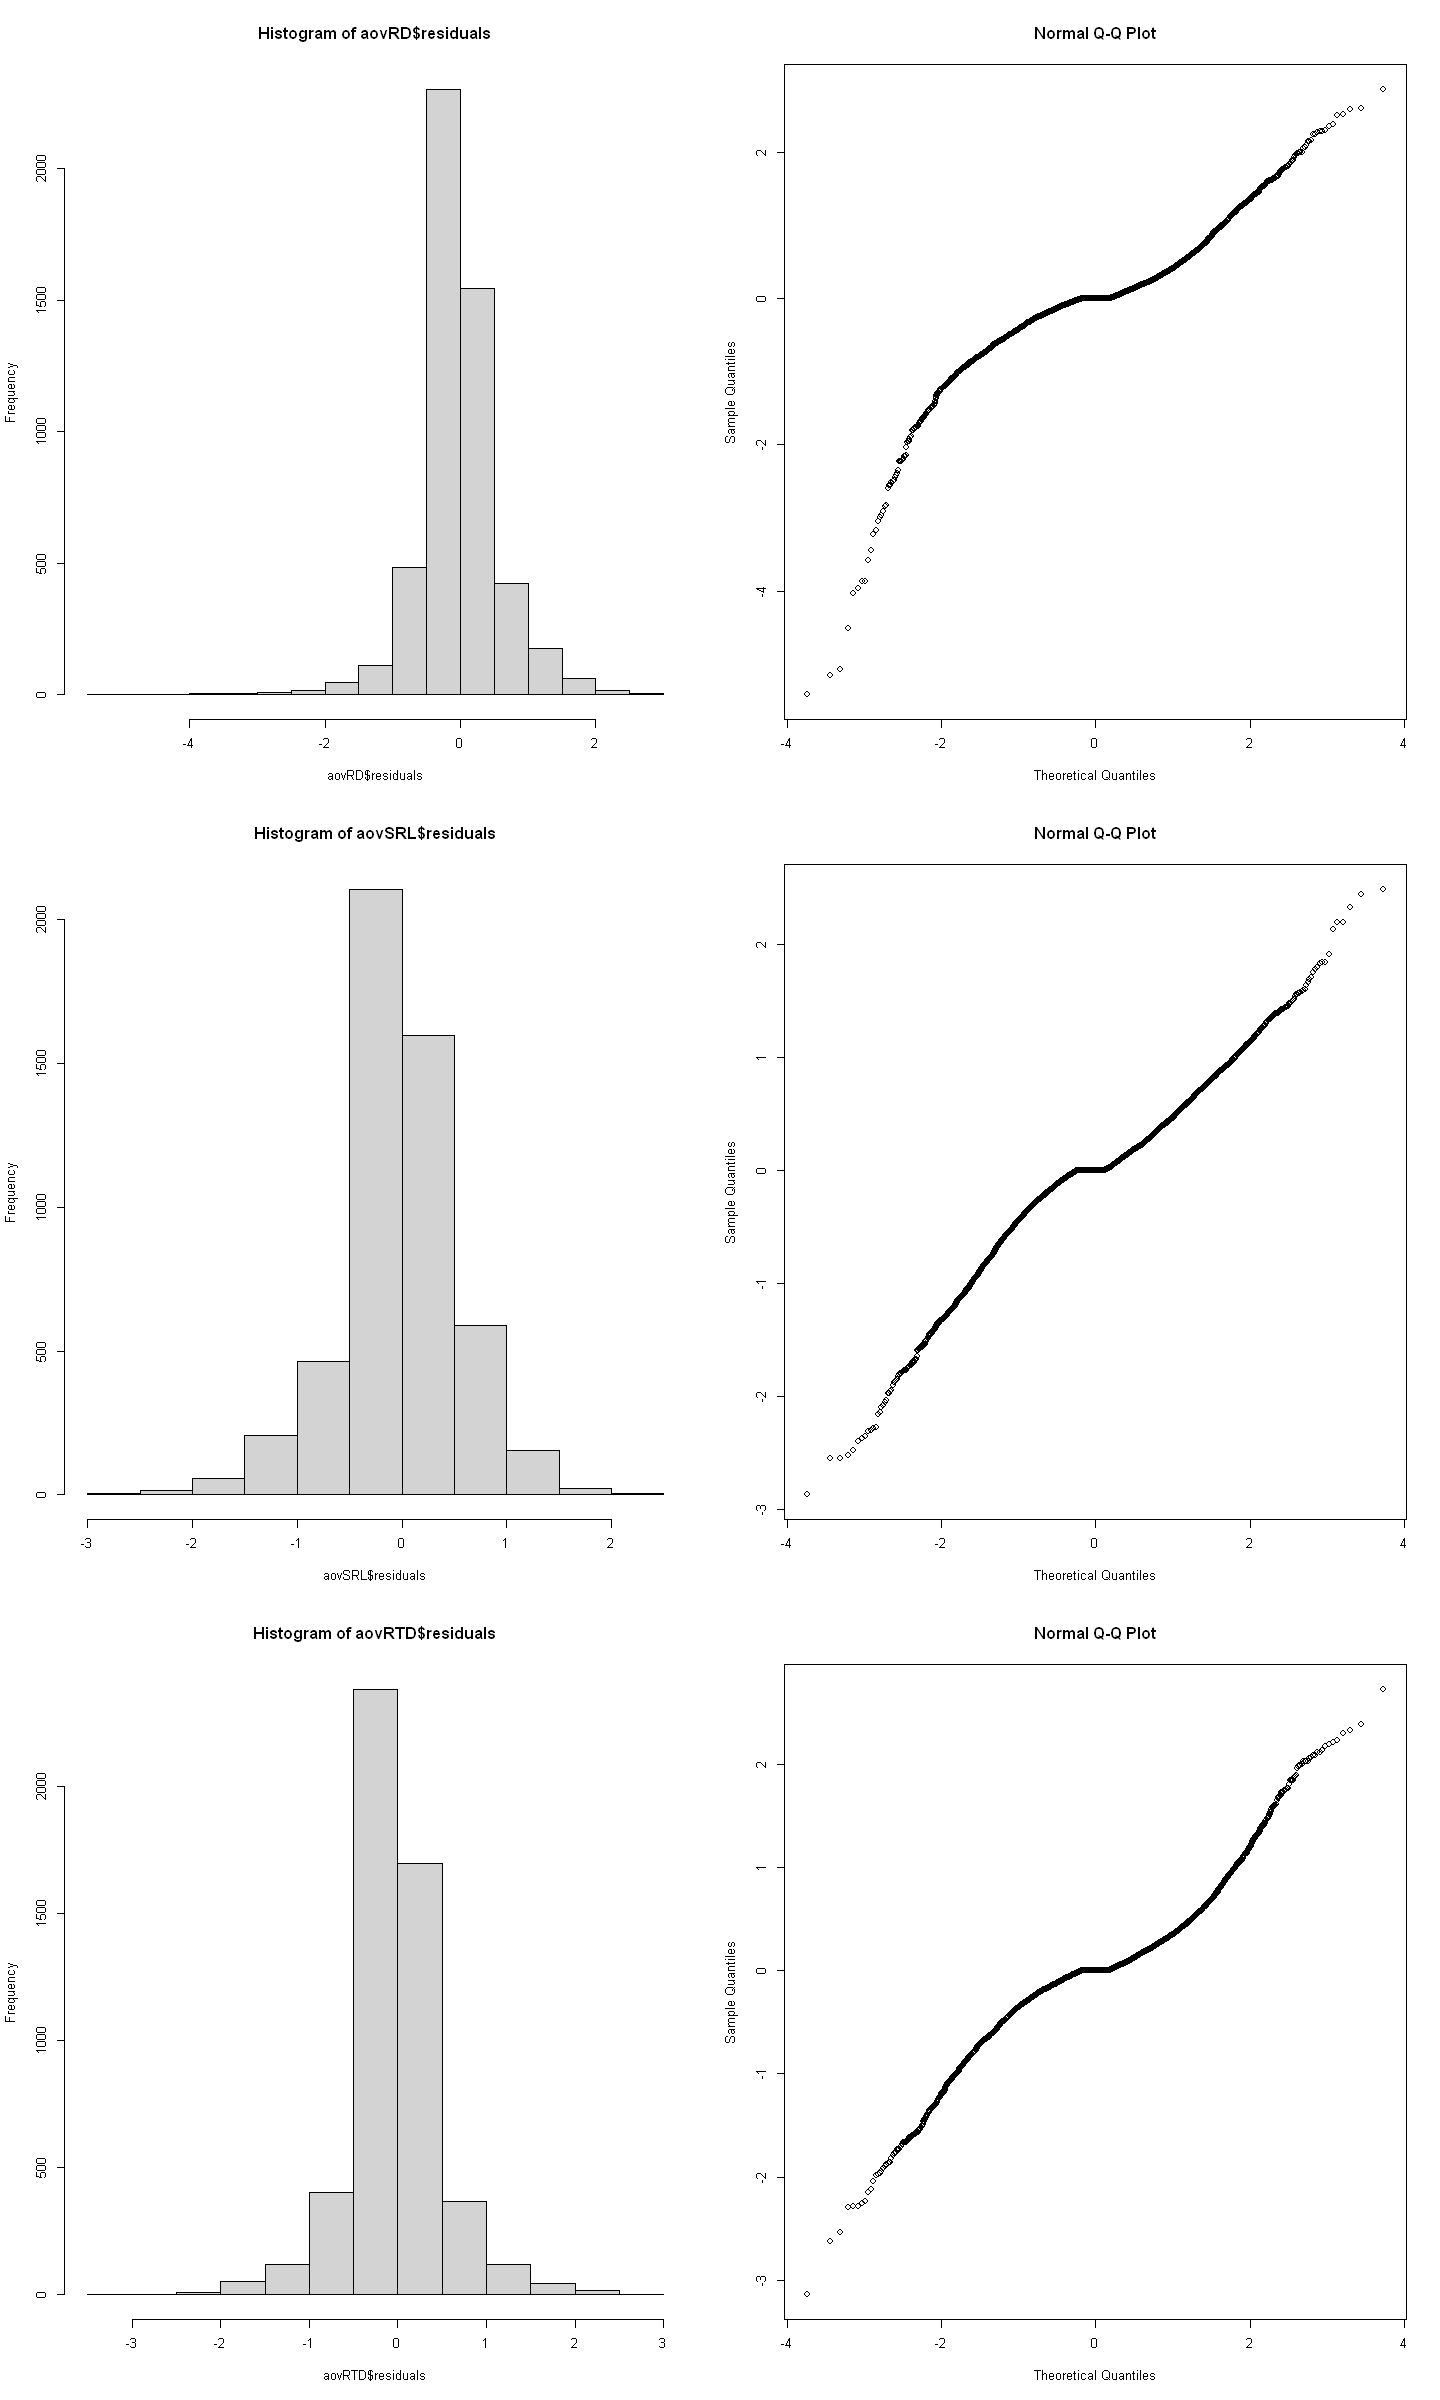

In [25]:
# let's check if the ANOVA preconditions are met

par(mfrow = c(3, 2))
options(repr.plot.width = 12, repr.plot.height = 20)

hist(aovRD$residuals)
qqnorm(aovRD$residuals)

hist(aovSRL$residuals)
qqnorm(aovSRL$residuals)

hist(aovRTD$residuals)
qqnorm(aovRTD$residuals)

In [26]:
shapiro.test(aovRD$residuals)

ERROR: Error in shapiro.test(aovRD$residuals): sample size must be between 3 and 5000


In [29]:
# Anderson-Darling normality test - an alternative to Shapiro-Wilk test which fails to handle more than 5000 observations

nortest::ad.test(aovRD$residuals)


	Anderson-Darling normality test

data:  aovRD$residuals
A = 154.7, p-value < 2.2e-16


In [30]:
nortest::ad.test(aovSRL$residuals)


	Anderson-Darling normality test

data:  aovSRL$residuals
A = 90.935, p-value < 2.2e-16


In [31]:
nortest::ad.test(aovRTD$residuals)


	Anderson-Darling normality test

data:  aovRTD$residuals
A = 147.66, p-value < 2.2e-16


In [34]:
# Remember that the null and alternative hypothesis of these tests are:
# H0: data come from a normal distribution
# H1: data do not come from a normal distribution

# since all Ps are < 0.05; we reject the null hypotheses - the data does not come from a normal dist :/
# since the normality precondition is violated - we cannot use Welch's test either

In [35]:
# second precondition of ANOVA is homogeneity of variances
# we can use Levene's test to confirm this

In [38]:
car::leveneTest(F00679~as.factor(binominal), data = fred4_raw)

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,1300,1.382423,1.014167e-13
,3917,NA,NA


In [39]:
car::leveneTest(F00727~as.factor(binominal), data = fred4_raw)

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,1300,1.863513,2.181077e-47
,3917,NA,NA


In [40]:
car::leveneTest(F00709~as.factor(binominal), data = fred4_raw)

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,1300,1.755621,7.863855e-39
,3917,NA,NA


In [45]:
# https://statsandr.com/blog/anova-in-r/
# The null and alternative hypothesis for Levene's test are:
# H0: variances are equal
# H1: at least one variance is different

# since the P values are < 0.05 for all traits - we reject the null hypotheses
# the homogeneity of variance assumption does not hold here

In [46]:
# https://statsandr.com/blog/kruskal-wallis-test-nonparametric-version-anova/

# Kruskal-Wallis is non-parametric 
# it does not have the normality precondition

# The null and alternative hypotheses of the Kruskal-Wallis test are:
# H0: The 3 species are equal in terms of flipper length
# H1: At least one species is different from the other 2 species in terms of flipper length

# Be careful that, as for the ANOVA, the alternative hypothesis is not that all species are different in terms of flipper length. 
# The opposite of all species being equal (H0) is that at least one species is different from the others (H1).

# Second, remember that the Kruskal-Wallis test is a nonparametric test, so the normality assumption is not required. However, the independence assumption still holds.
# This means that the data, collected from a representative and randomly selected portion of the total population, should be independent between groups and within each group
# Regarding the homoscedasticity (i.e., equality of the variances): As long as you use the Kruskal-Wallis test to, in fine, compare groups, homoscedasticity is not required. 
# If you wish to compare medians, the Kruskal-Wallis test requires homoscedasticity.

In [7]:
kruskal.test(F00679~binominal, data = fred4_raw)


	Kruskal-Wallis rank sum test

data:  F00679 by binominal
Kruskal-Wallis chi-squared = 3290, df = 1300, p-value < 2.2e-16


In [8]:
kruskal.test(F00727~binominal, data = fred4_raw)


	Kruskal-Wallis rank sum test

data:  F00727 by binominal
Kruskal-Wallis chi-squared = 3359.1, df = 1300, p-value < 2.2e-16


In [9]:
kruskal.test(F00709~binominal, data = fred4_raw)


	Kruskal-Wallis rank sum test

data:  F00709 by binominal
Kruskal-Wallis chi-squared = 3789.5, df = 1300, p-value < 2.2e-16


In [52]:
# since the p values are < 0.05 for all the traits - we reject the H0
# however Kruskall-Wallis do not tell us which groups significantly differ from one another - just that there's at least one group that deviates from the whole

In [53]:
# to see which actually do - we can use Dunn's test

In [ ]:
# dunnTest spits out a lot of stuff - maxxes out the memory
# the outputs of FSA::dunnTest are actually wrnings - not simple print messages

suppressWarnings({
    dunnRD <- FSA::dunnTest(F00679~as.factor(binominal), data = fred4_raw, method = "holm");
    dunnSRL <- FSA::dunnTest(F00727~as.factor(binominal), data = fred4_raw, method = "holm");
    dunnRTD <- FSA::dunnTest(F00709~as.factor(binominal), data = fred4_raw, method = "holm");
})

  Kruskal-Wallis rank sum test

data: x and g
Kruskal-Wallis chi-squared = 3289.982, df = 1300, p-value = 0



## ___`ape::vcv.phylo(corr = ?)`___
-----------------

In [3]:
# compare the correlation matrix with the variance-covariance matrix

In [4]:
tree <- ape::read.tree("../../data/chapter2/uphylomaker/FRED4_1301.tre")

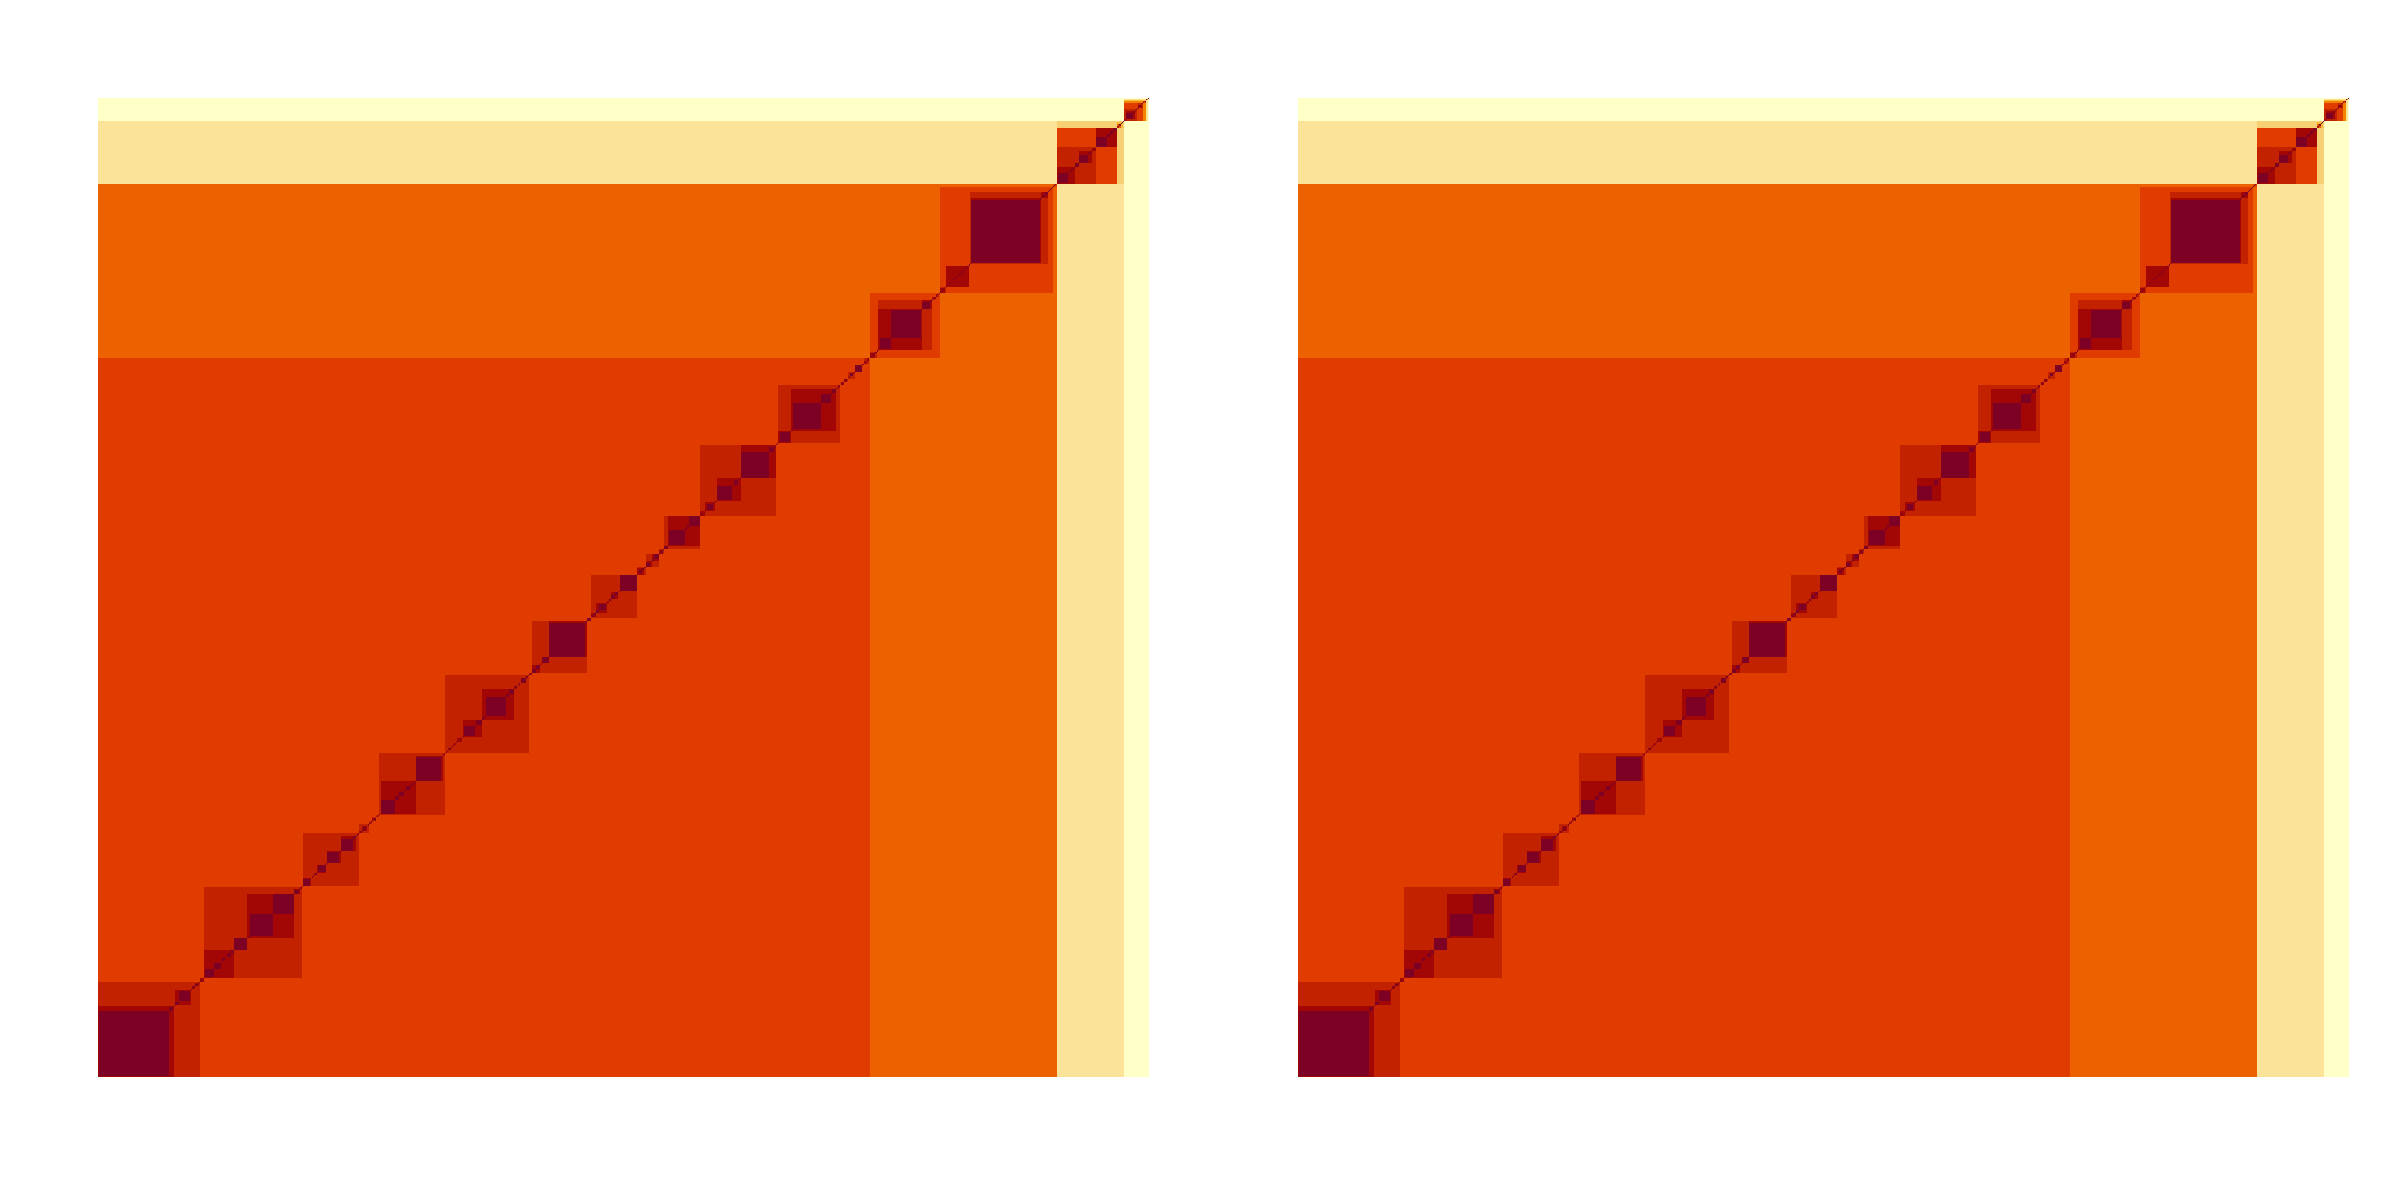

In [15]:
par(mfrow = c(1, 2))
options(repr.plot.width = 20, repr.plot.height = 10)
image(ape::vcv.phylo(tree, corr = FALSE), axes = FALSE) # correlation matrix
image(ape::vcv.phylo(tree, corr = TRUE), axes = FALSE) # covariance matrix

In [21]:
# plots look identical
(ape::vcv.phylo(tree, corr = FALSE) == ape::vcv.phylo(tree, corr = FALSE)) |> mean()

[1] 1

In [22]:
# both matrices are in-fact identical - so doesn't matter which matrix we used in brms :)